# PASSO 3 - Treinamento de Modelo (Random Forest)
Nesse passo, vamos treinar modelos Random Forest para cada traço de personalidade MBTI.

## 0. Setup
Importar os pacotes necessários para rodar o resto do código.

In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score
from pipeline.smote_oversampling import SMOTEOversampler
from pipeline.machine_learning_algorithms.random_forest import RandomForestModel

## 1. Carregando os Dados
Primeiro, vamos carregar os datasets e aplicar oversampling.


In [ ]:
print("Loading datasets...")
with open("../train_datasets/train_datasets/X_train_tfidf.pkl", "rb") as file:
    X_train_tf = pickle.load(file)
with open("../test_datasets/test_datasets/X_test_tfidf.pkl", "rb") as file:
    X_test_tf = pickle.load(file)
with open("../train_datasets/train_datasets/y_train.pkl", "rb") as file:
    y_train = pd.Series(pickle.load(file))
with open("../test_datasets/test_datasets/y_test.pkl", "rb") as file:
    y_test = pd.Series(pickle.load(file))

Loading datasets...


In [ ]:
def divide_mbti(y_series):
    y_df = pd.DataFrame()
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)
    return y_df

In [ ]:
y_test_4cols = divide_mbti(y_test)

## 2. Rastreador de Métricas

Inicialização do dicionário para registrar e organizar os F1-scores dos modelos nos três cenários de teste (Baseline, SMOTE e SLM Augmentation). Serve como base para a criação do gráfico comparativo.

In [ ]:
dimensions = ['I_E', 'N_S', 'T_F', 'J_P']

comparison_metrics = {
    'TF_IDF': {
        dim: {'base_no_smote': {},
              'base_smote': {}, 
              'aug_smote': {}}
              for dim in dimensions},

    'Word2Vec': { dim: {'base_no_smote': {},
                  'base_smote': {}, 
                  'aug_smote': {}}
                  for dim in dimensions}
}

print("Metrics tracker initialized with 3 stages per dimension")

Metrics tracker initialized with 3 stages per dimension


## 3. TF-IDF

Agora, vamos treinar o modelo para os três cenários de teste, em todas as quatro dimensões do MBTI, utilizando os as features extraídas com TF-IDF.

In [ ]:
smote = SMOTEOversampler(random_state=42)


for dim in dimensions:
    print(f"\n=================== TF-IDF: EIXO {dim} ===================")
    
    # --- EXPERIMENT 1: Base (No SMOTE) - Primeiras 6640 linhas ---
    X_train_e1 = X_train_tf[:6640].astype(np.float32)
    y_train_e1 = y_train[:6640]
    y_train_e1_4cols = divide_mbti(pd.Series(y_train_e1))
    
    rf1 = RandomForestModel()
    opt1 = rf1.get_optimizer()
    opt1.fit(X_train_e1, y_train_e1_4cols[dim])
    rf1.set_best_model(opt1.best_estimator_)
    acc1, prec1, rec1, f1_1, _ = rf1.evaluate(X_test_tf, y_test_4cols[dim])
    comparison_metrics['TF_IDF'][dim]['base_no_smote'] = {'f1_score': f1_1}
    print(f"[1. Base] F1-Score: {f1_1:.4f}")

    # --- EXPERIMENTO 2: SMOTE Only - Primeiras 6640 linhas ---
    X_train_e2, y_train_e2 = smote.fit_resample(X_train_tf[:6640], y_train[:6640])
    X_train_e2 = X_train_e2.astype(np.float32)
    y_train_e2_4cols = divide_mbti(pd.Series(y_train_e2))
    
    rf2 = RandomForestModel()
    opt2 = rf2.get_optimizer()
    opt2.fit(X_train_e2, y_train_e2_4cols[dim])
    rf2.set_best_model(opt2.best_estimator_)
    acc2, prec2, rec2, f1_2, _ = rf2.evaluate(X_test_tf, y_test_4cols[dim])
    comparison_metrics['TF_IDF'][dim]['base_smote'] = {'f1_score': f1_2}
    print(f"[2. SMOTE Only] F1-Score: {f1_2:.4f}")

    # --- EXPERIMENTO 3: SLM Aug + SMOTE - Dataset Completo ---
    X_train_e3, y_train_e3 = smote.fit_resample(X_train_tf, y_train)
    X_train_e3 = X_train_e3.astype(np.float32)
    y_train_e3_4cols = divide_mbti(pd.Series(y_train_e3))
    
    rf3 = RandomForestModel()
    opt3 = rf3.get_optimizer()
    opt3.fit(X_train_e3, y_train_e3_4cols[dim])
    rf3.set_best_model(opt3.best_estimator_)
    acc3, prec3, rec3, f1_3, _ = rf3.evaluate(X_test_tf, y_test_4cols[dim])
    comparison_metrics['TF_IDF'][dim]['aug_smote'] = {'f1_score': f1_3}
    print(f"[3. SLM Aug + SMOTE] F1-Score: {f1_3:.4f}")


=================== TF-IDF: EIXO I_E ===================
[1. Base] F1-Score: 0.4347
Original dataset shape: X=(6640, 10000), y=(6640,)
Resampled dataset shape: X=(22320, 10000), y=(22320,)
[2. SMOTE Only] F1-Score: 0.4391
Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
[3. SLM Aug + SMOTE] F1-Score: 0.4587

=================== TF-IDF: EIXO N_S ===================
[1. Base] F1-Score: 0.4628
Original dataset shape: X=(6640, 10000), y=(6640,)
Resampled dataset shape: X=(22320, 10000), y=(22320,)
[2. SMOTE Only] F1-Score: 0.4670
Original dataset shape: X=(9322, 10000), y=(9322,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)
[3. SLM Aug + SMOTE] F1-Score: 0.4628

=================== TF-IDF: EIXO T_F ===================
[1. Base] F1-Score: 0.7523
Original dataset shape: X=(6640, 10000), y=(6640,)
Resampled dataset shape: X=(22320, 10000), y=(22320,)
[2. SMOTE Only] F1-Score: 0.7534
Original dataset shape: X=(9322, 10000), y=(9

## 4. WORD2VEC

Aplicamos a mesma estrutura de experimentos através dos quatro eixos de personalidade, utilizando os embeddings do Word2Vec.

In [ ]:
print("--- Loading Word2Vec datasets ---")
with open("../train_datasets/train_datasets/X_train_w2v.pkl", "rb") as file:
    X_train_w2v = pickle.load(file)
with open("../test_datasets/test_datasets/X_test_w2v.pkl", "rb") as file:
    X_test_w2v = pickle.load(file)

for dim in dimensions:
    print(f"\n=================== WORD2VEC: AXIS {dim} ===================")
    
    # --- EXPERIMENTO 1: Base (No SMOTE) ---
    X_train_e1 = X_train_w2v[:6640].astype(np.float32)
    y_train_e1 = y_train[:6640]
    y_train_e1_4cols = divide_mbti(pd.Series(y_train_e1))
    
    rf1 = RandomForestModel()
    opt1 = rf1.get_optimizer()
    opt1.fit(X_train_e1, y_train_e1_4cols[dim])
    rf1.set_best_model(opt1.best_estimator_)
    _, _, _, f1_1, _ = rf1.evaluate(X_test_w2v, y_test_4cols[dim])
    comparison_metrics['Word2Vec'][dim]['base_no_smote'] = {'f1_score': f1_1}
    print(f"[1. Base] F1-Score: {f1_1:.4f}")

    # --- EXPERIMENTO 2: SMOTE Only ---
    X_train_e2, y_train_e2 = smote.fit_resample(X_train_w2v[:6640], y_train[:6640])
    X_train_e2 = X_train_e2.astype(np.float32)
    y_train_e2_4cols = divide_mbti(pd.Series(y_train_e2))
    
    rf2 = RandomForestModel()
    opt2 = rf2.get_optimizer()
    opt2.fit(X_train_e2, y_train_e2_4cols[dim])
    rf2.set_best_model(opt2.best_estimator_)
    _, _, _, f1_2, _ = rf2.evaluate(X_test_w2v, y_test_4cols[dim])
    comparison_metrics['Word2Vec'][dim]['base_smote'] = {'f1_score': f1_2}
    print(f"[2. SMOTE Only] F1-Score: {f1_2:.4f}")

    # --- EXPERIMENTO 3: SLM Aug + SMOTE ---
    X_train_e3, y_train_e3 = smote.fit_resample(X_train_w2v, y_train)
    X_train_e3 = X_train_e3.astype(np.float32)
    y_train_e3_4cols = divide_mbti(pd.Series(y_train_e3))
    
    rf3 = RandomForestModel()
    opt3 = rf3.get_optimizer()
    opt3.fit(X_train_e3, y_train_e3_4cols[dim])
    rf3.set_best_model(opt3.best_estimator_)
    _, _, _, f1_3, _ = rf3.evaluate(X_test_w2v, y_test_4cols[dim])
    comparison_metrics['Word2Vec'][dim]['aug_smote'] = {'f1_score': f1_3}
    print(f"[3. SLM Aug + SMOTE] F1-Score: {f1_3:.4f}")

--- Loading Word2Vec datasets ---

=================== WORD2VEC: AXIS I_E ===================
[1. Base] F1-Score: 0.4822
Original dataset shape: X=(6640, 500), y=(6640,)
Resampled dataset shape: X=(22320, 500), y=(22320,)
[2. SMOTE Only] F1-Score: 0.5595
Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
[3. SLM Aug + SMOTE] F1-Score: 0.5260

=================== WORD2VEC: AXIS N_S ===================
[1. Base] F1-Score: 0.4737
Original dataset shape: X=(6640, 500), y=(6640,)
Resampled dataset shape: X=(22320, 500), y=(22320,)
[2. SMOTE Only] F1-Score: 0.5362
Original dataset shape: X=(9322, 500), y=(9322,)
Resampled dataset shape: X=(23456, 500), y=(23456,)
[3. SLM Aug + SMOTE] F1-Score: 0.5070

=================== WORD2VEC: AXIS T_F ===================
[1. Base] F1-Score: 0.7318
Original dataset shape: X=(6640, 500), y=(6640,)
Resampled dataset shape: X=(22320, 500), y=(22320,)
[2. SMOTE Only] F1-Score: 0.7361
Original dataset shape: X

## 5. Geração dos Gráficos
Agora, iremos gerar os gráficos de barras comparativos de 3 estágios para TF-IDF e Word2Vec.

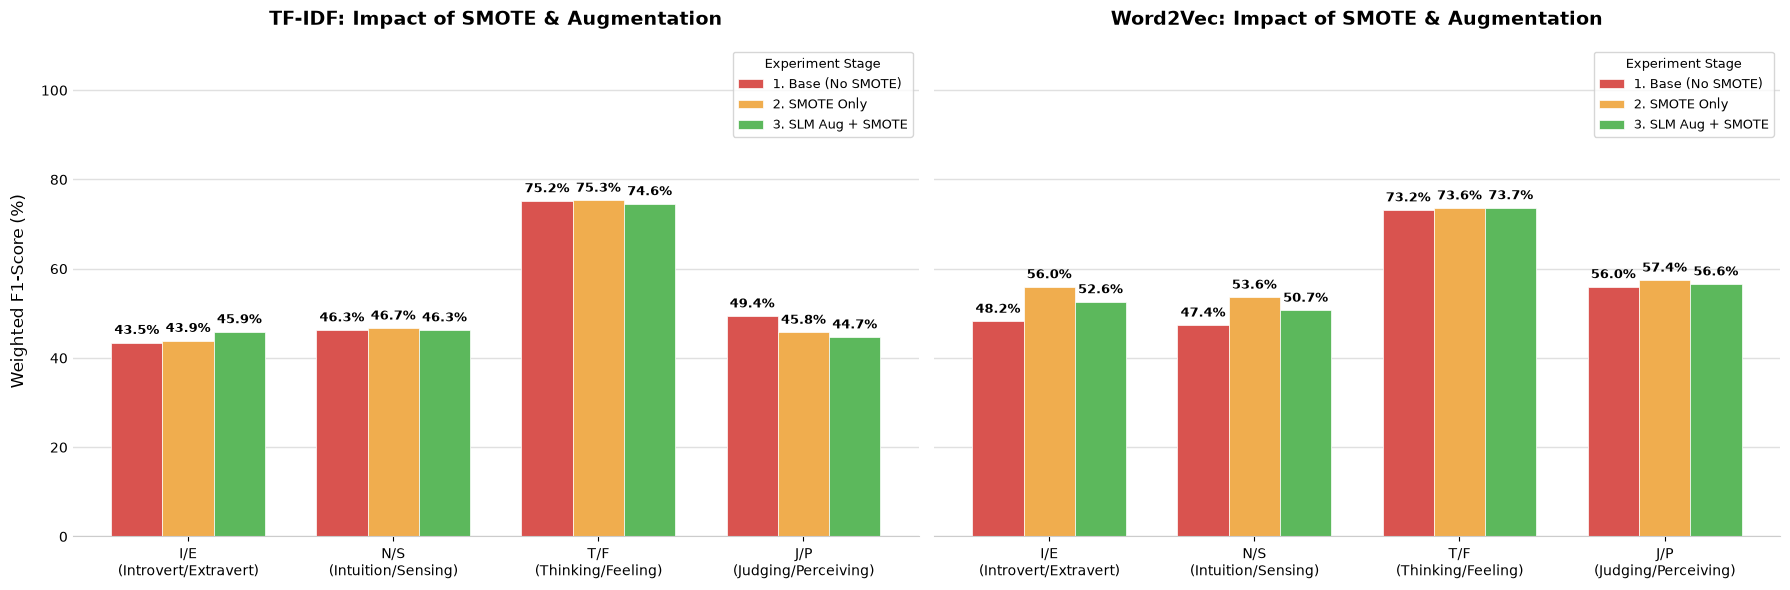

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_f1_impact_custom():
    labels_display = [
        'I/E\n(Introvert/Extravert)', 
        'N/S\n(Intuition/Sensing)', 
        'T/F\n(Thinking/Feeling)', 
        'J/P\n(Judging/Perceiving)'
    ]
    dict_keys = ['I_E', 'N_S', 'T_F', 'J_P']
    x = np.arange(len(labels_display))
    width = 0.25 
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    
    color_base = '#D9534F'   
    color_smote = '#F0AD4E'  
    color_aug = '#5CB85C'    
    
    titles = ['TF-IDF: Impact of SMOTE & Augmentation', 'Word2Vec: Impact of SMOTE & Augmentation']
    encodings = ['TF_IDF', 'Word2Vec']
    
    for idx, encoding in enumerate(encodings):
        ax = axes[idx]
        
        base_scores = [comparison_metrics[encoding][dim]['base_no_smote']['f1_score'] * 100 for dim in dict_keys]
        smote_scores = [comparison_metrics[encoding][dim]['base_smote']['f1_score'] * 100 for dim in dict_keys]
        aug_scores = [comparison_metrics[encoding][dim]['aug_smote']['f1_score'] * 100 for dim in dict_keys]
        
        rects1 = ax.bar(x - width, base_scores, width, label='1. Base (No SMOTE)', color=color_base, edgecolor='white', linewidth=0.5)
        rects2 = ax.bar(x, smote_scores, width, label='2. SMOTE Only', color=color_smote, edgecolor='white', linewidth=0.5)
        rects3 = ax.bar(x + width, aug_scores, width, label='3. SLM Aug + SMOTE', color=color_aug, edgecolor='white', linewidth=0.5)
        
        ax.set_title(titles[idx], fontsize=14, fontweight='bold', pad=15)
        if idx == 0:
            ax.set_ylabel('Weighted F1-Score (%)', fontsize=12, labelpad=10)
        
        ax.set_xticks(x)
        ax.set_xticklabels(labels_display, fontsize=10)
        ax.set_ylim(0, 110)
        ax.yaxis.grid(True, color='#E0E0E0', linestyle='-', linewidth=1)
        ax.set_axisbelow(True)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#CCCCCC')
        ax.tick_params(axis='y', length=0)
        
        ax.legend(title='Experiment Stage', loc='upper right', fontsize=9, title_fontsize=9)
        
        def add_labels(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', 
                            fontsize=9, fontweight='bold')
        
        add_labels(rects1)
        add_labels(rects2)
        add_labels(rects3)

    plt.tight_layout()
    plt.show()

plot_f1_impact_custom()